In [ ]:
import warnings
warnings.filterwarnings('ignore')

Generating sample raw dataset...
Saved 'raw_dataset.csv'

--- INITIAL DATA SUMMARY ---
Shape before cleaning: (15, 5)
Employee_ID         0
Department          1
Age                 2
Salary              2
Experience_Years    0
dtype: int64

[+] Removed 1 duplicate row(s).
[+] Filled missing numerical values with column median.
[+] Filled missing department values with mode.
[+] Outliers capped using IQR bounds.
Saved 'cleaned_dataset.csv'

Generating visualization dashboard...


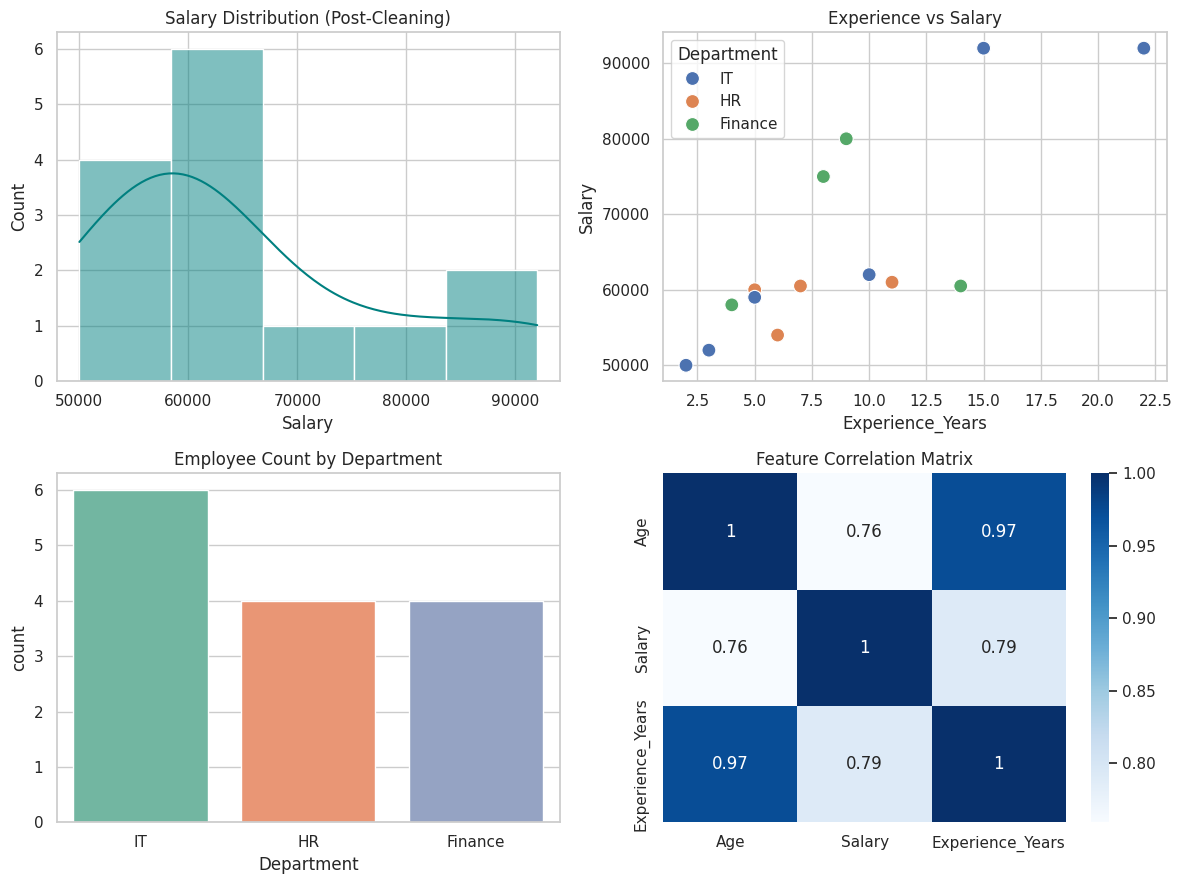

=== PIPELINE COMPLETED SUCCESSFULLY ===


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart style
sns.set_theme(style="whitegrid")

# 1. GENERATE SAMPLE RAW DATASET
print("Generating sample raw dataset...")
np.random.seed(42)

data = {
    'Employee_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 101, 112, 113, 114, 115],
    'Department': ['IT', 'HR', 'Finance', 'IT', 'Finance', 'HR', None, 'IT', 'Finance', 'HR', 'IT', 'IT', 'HR', 'Finance', 'IT'],
    'Age': [25, 30, np.nan, 45, 29, 35, 40, 50, np.nan, 31, 25, 28, 38, 42, 33],
    'Salary': [50000, 60000, 75000, 120000, 58000, np.nan, 62000, 250000, 80000, 54000, 50000, 52000, 61000, np.nan, 59000], # 250k is an outlier
    'Experience_Years': [2, 5, 8, 15, 4, 7, 10, 22, 9, 6, 2, 3, 11, 14, 5]
}

raw_df = pd.DataFrame(data)
raw_df.to_csv('raw_dataset.csv', index=False)
print("Saved 'raw_dataset.csv'\n")

# 2. DATA CLEANING & PREPROCESSING
df = pd.read_csv('raw_dataset.csv')

print("--- INITIAL DATA SUMMARY ---")
print(f"Shape before cleaning: {df.shape}")
print(df.isnull().sum())

# A. Remove Duplicate Rows
duplicates_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"\n[+] Removed {duplicates_count} duplicate row(s).")

# B. Handle Missing Numerical Values (Replace missing with Median)
for col in ['Age', 'Salary']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
print("[+] Filled missing numerical values with column median.")

# C. Handle Missing Categorical Values (Replace missing with Mode)
mode_dept = df['Department'].mode()[0]
df['Department'].fillna(mode_dept, inplace=True)
print("[+] Filled missing department values with mode.")

# D. Handle Outliers (Capping Salary using IQR method)
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# Cap extreme high values
df['Salary'] = np.where(df['Salary'] > upper_limit, upper_limit, df['Salary'])
print("[+] Outliers capped using IQR bounds.")

# Save Cleaned Dataset
df.to_csv('cleaned_dataset.csv', index=False)
print("Saved 'cleaned_dataset.csv'\n")

# 3. DATA VISUALIZATION
print("Generating visualization dashboard...")
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Chart 1: Salary Distribution
sns.histplot(df['Salary'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Salary Distribution (Post-Cleaning)')

# Chart 2: Experience vs Salary
sns.scatterplot(data=df, x='Experience_Years', y='Salary', hue='Department', s=100, ax=axes[0, 1])
axes[0, 1].set_title('Experience vs Salary')

# Chart 3: Department Count
sns.countplot(data=df, x='Department', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Employee Count by Department')

# Chart 4: Heatmap Correlation
sns.heatmap(df[['Age', 'Salary', 'Experience_Years']].corr(), annot=True, cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('dashboard.png')
plt.show()
print("=== PIPELINE COMPLETED SUCCESSFULLY ===")